# Mock data — Case Study 1

This notebook creates the two small datasets used in **Case Study 1**:

- `data/dataset_NPSY.csv` — demographics (age, sex, cognitive reserve) and neuropsychological test scores
- `data/dataset_P300.csv` — EEG features already extracted from the signal (P300 and N400 amplitude and latency)

The data are **synthetic (mock)**: we invent them. The advantage is that *we* decide in advance which associations exist, so the case study can show the analysis working on data where we know the truth.

The golden rule of this notebook is **simplicity**. Every variable is built the same way:

```
value = base value + effect of other variables + random noise
```

Here is the complete "recipe" in one table:

| Column | What it is | How it is built |
|---|---|---|
| `age` | age in years (40–90) | random |
| `sex` | 0 = female, 1 = male | random |
| `criq` | cognitive reserve (70–130) | random, slightly lower in older participants |
| `n400_amp` | N400 amplitude (µV) | random, 1–6 |
| `n400_lat` | N400 latency (ms) | gets longer with age + noise |
| `p300_amp` | P300 amplitude (µV) | random, 5–20 |
| `p300_lat` | P300 latency (ms) | gets longer with age + noise |
| `matrix` | Attentive Matrices (0–60) | **+ P300 amplitude**, − age, + criq |
| `apacs` | APACS, communication (0–1) | **+ N400 amplitude, − N400 latency**, − age, + criq |
| `moca` | MoCA, cognition (0–30) | small ERP effects, − age, + criq |

The bold effects are the ones the case study should rediscover: **P300 ↔ attention (Matrici)** and **N400 ↔ language (APACS)**.

## 1. Setup

We import the libraries we need and set two knobs:

- `N_SUBJECTS` — how many participants to generate
- `SEED` — a number that makes the random draws *reproducible*: run the notebook again and you get exactly the same data

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_style("whitegrid")

N_SUBJECTS = 40
SEED = 42

rng = np.random.default_rng(SEED)
print(f"We will generate {N_SUBJECTS} participants.")
print("Fixed seed -> same data every time the notebook is re-run.")

We will generate 40 participants.
Fixed seed -> same data every time the notebook is re-run.


## 2. Step 1 — Demographics

Three basic variables:

- `age` — drawn from a normal distribution centred on 65 years, kept between 40 and 90
- `sex` — a coin flip (0 = female, 1 = male)
- `criq` — Cognitive Reserve Index (mean ~100): a random value that is slightly *lower* for older participants

In [102]:
age  = np.clip(np.round(rng.normal(65, 10, N_SUBJECTS)), 40, 90)
sex  = rng.binomial(1, 0.5, N_SUBJECTS)
criq = np.clip(100 + 15 * rng.normal(0, 1, N_SUBJECTS) - 0.3 * (age - 65), 70, 130)

print(f"Age:  mean {age.mean():.1f}, range [{age.min():.0f}, {age.max():.0f}]")
print(f"CRIq: mean {criq.mean():.1f}, range [{criq.min():.0f}, {criq.max():.0f}]")
print(f"Sex:  {int(sex.sum())} male, {int(N_SUBJECTS - sex.sum())} female")

Age:  mean 65.4, range [45, 86]
CRIq: mean 96.0, range [73, 120]
Sex:  20 male, 20 female


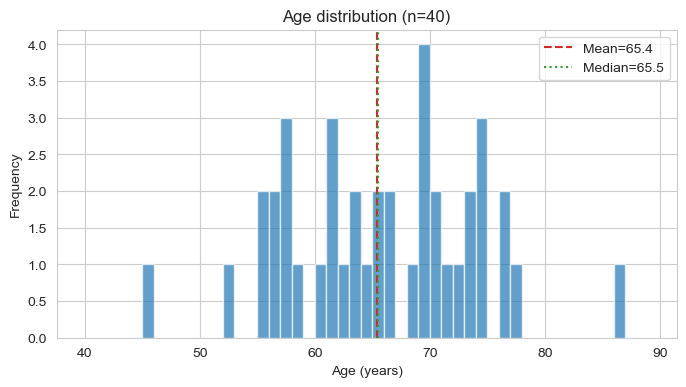

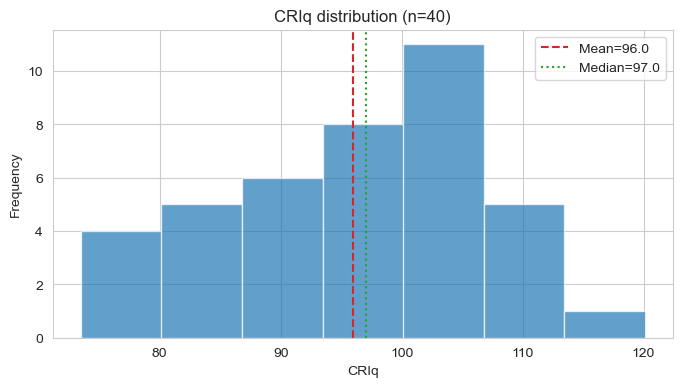

/tmp/ipykernel_212795/2638674471.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


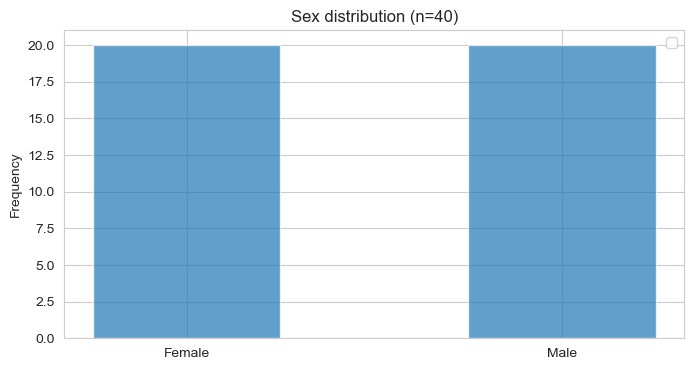

In [103]:
plt.figure(figsize=(8, 4))
plt.hist(age, bins=range(40, 90), edgecolor='white', alpha=0.7)
plt.axvline(np.mean(age), color='C3', ls='--', label=f'Mean={np.mean(age):.1f}')
plt.axvline(np.median(age), color='C2', ls=':', label=f'Median={np.median(age):.1f}')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.title(f'Age distribution (n={N_SUBJECTS})')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(criq, bins="auto", edgecolor='white', alpha=0.7)
plt.axvline(np.mean(criq), color='C3', ls='--', label=f'Mean={np.mean(criq):.1f}')
plt.axvline(np.median(criq), color='C2', ls=':', label=f'Median={np.median(criq):.1f}')
plt.xlabel('CRIq')
plt.ylabel('Frequency')
plt.title(f'CRIq distribution (n={N_SUBJECTS})')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
counts = [(sex == 0).sum(), (sex == 1).sum()]
plt.bar(['Female', 'Male'], counts, width=0.5, edgecolor='white', alpha=0.7)
plt.ylabel('Frequency')
plt.title(f'Sex distribution (n={N_SUBJECTS})')
plt.legend()
plt.show()

## 3. Step 2 — ERP features

Each participant has four EEG features, already extracted from the signal (this is the **dimensionality reduction** idea of Case Study 1 — the whole EEG is summarised by four numbers).

- **N400**: a brain response ~400 ms after a meaningful word; indexes *language / semantic processing*
  - `n400_amp` amplitude (µV) — larger in better performers
  - `n400_lat` latency (ms) — *longer* (slower) with age
- **P300**: a brain response ~300 ms after a target; indexes *attention*
  - `p300_amp` amplitude (µV) — larger in better performers
  - `p300_lat` latency (ms) — *longer* (slower) with age

Latency depends on age; amplitude is just base value + noise. Everything is clipped to realistic clinical ranges.

In [104]:
n400_amp = np.clip(3.5 + 0.8 * rng.normal(0, 1, N_SUBJECTS), 1, 6)
n400_lat = np.clip(425 + 0.5 * (age - 65) + 15 * rng.normal(0, 1, N_SUBJECTS), 350, 500)

p300_amp = np.clip(12.5 + 1.8 * rng.normal(0, 1, N_SUBJECTS), 5, 20)
p300_lat = np.clip(350 + 0.5 * (age - 65) + 15 * rng.normal(0, 1, N_SUBJECTS), 300, 450)

for name, vals in [("n400_amp", n400_amp), ("n400_lat", n400_lat),
                   ("p300_amp", p300_amp), ("p300_lat", p300_lat)]:
    print(f"{name:<10} mean {vals.mean():6.1f}  range [{vals.min():6.1f}, {vals.max():6.1f}]")

n400_amp   mean    3.5  range [   1.8,    5.8]
n400_lat   mean  426.0  range [ 402.1,  453.2]
p300_amp   mean   12.3  range [   8.6,   17.0]
p300_lat   mean  350.3  range [ 313.6,  398.1]


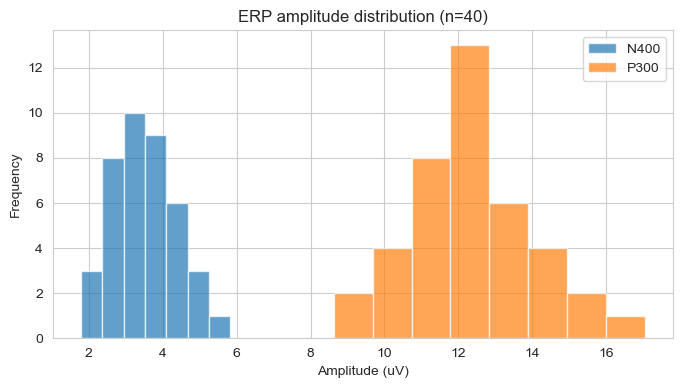

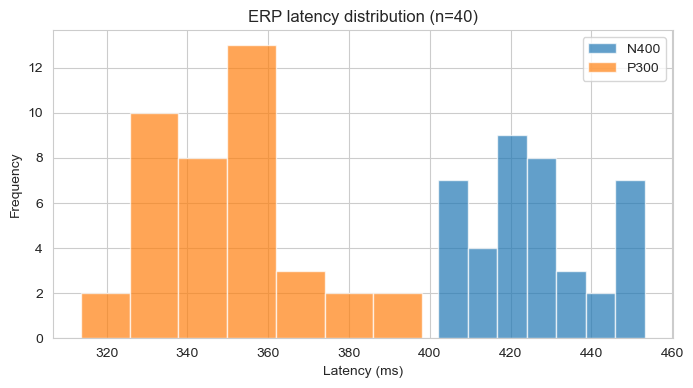

In [105]:
plt.figure(figsize=(8, 4))
plt.hist(n400_amp, bins='auto', edgecolor='white', alpha=0.7, label="N400")
plt.hist(p300_amp, bins='auto', edgecolor='white', alpha=0.7, label="P300")
plt.xlabel('Amplitude (uV)')
plt.ylabel('Frequency')
plt.title(f'ERP amplitude distribution (n={N_SUBJECTS})')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(n400_lat, bins='auto', edgecolor='white', alpha=0.7, label="N400")
plt.hist(p300_lat, bins='auto', edgecolor='white', alpha=0.7, label="P300")
plt.xlabel('Latency (ms)')
plt.ylabel('Frequency')
plt.title(f'ERP latency distribution (n={N_SUBJECTS})')
plt.legend()
plt.show()

## 4. Step 3 — Neuropsychological test scores

Three test scores. **This is where we decide which associations exist**, because each score is built from the ERP features and demographics that make clinical sense.

**Attentive Matrices** (0–60) measures attention. Its strongest EEG correlate is the **P300 amplitude** (attention marker):

```
att_matr = 50 + 3.0·(p300_amp − 12.5) − 0.3·(age − 65) + 0.3·(criq − 100) + noise
```

In words: the score starts at 50, goes up ~3 points for each extra µV of P300 amplitude, and down with older age.

**APACS** (0–1) measures language/communication. Its correlates are the **N400 amplitude and latency** (language markers):

```
apacs = 0.75 + 0.02·(n400_amp − 3.5) − 0.0015·(n400_lat − 425) − 0.004·(age − 65) + 0.001·(criq − 100) + noise
```

**MoCA** (0–30) measures global cognition and depends only weakly on the ERP features (mostly age and cognitive reserve).

> Note: `sex` never appears in the formulas — we expect it to have no effect in the case study. A covariate that does nothing is a useful teaching example.

In [106]:
att_matr = np.clip(np.round(40 + 4.0 * (p300_amp - 12.5) - 0.7 * (age - 65)
                            + 0.7 * (criq - 100) + 6 * rng.normal(0, 1, N_SUBJECTS)),
                            0, 100)

apacs = np.clip(0.75 + 0.02 * (n400_amp - 3.5) - 0.0015 * (n400_lat - 425)
                - 0.004 * (age - 65) + 0.001 * (criq - 100) + 0.04 * rng.normal(0, 1, N_SUBJECTS),
                0, 1)

moca = np.clip(22 + 0.2 * (n400_amp - 3.5) - 0.01 * (n400_lat - 425)
               + 0.05 * (p300_amp - 12.5) - 0.01 * (p300_lat - 375)
               - 0.12 * (age - 65) + 0.04 * (criq - 100) + 2.5 * rng.normal(0, 1, N_SUBJECTS),
               0, 30)

for name, vals in [("att. matr.", att_matr), ("apacs", apacs), ("moca", moca)]:
    print(f"{name:<10} mean {vals.mean():5.2f}  range [{vals.min():5.2f}, {vals.max():5.2f}]")

att. matr. mean 36.88  range [ 5.00, 61.00]
apacs      mean  0.75  range [ 0.57,  0.88]
moca       mean 22.05  range [16.72, 28.41]


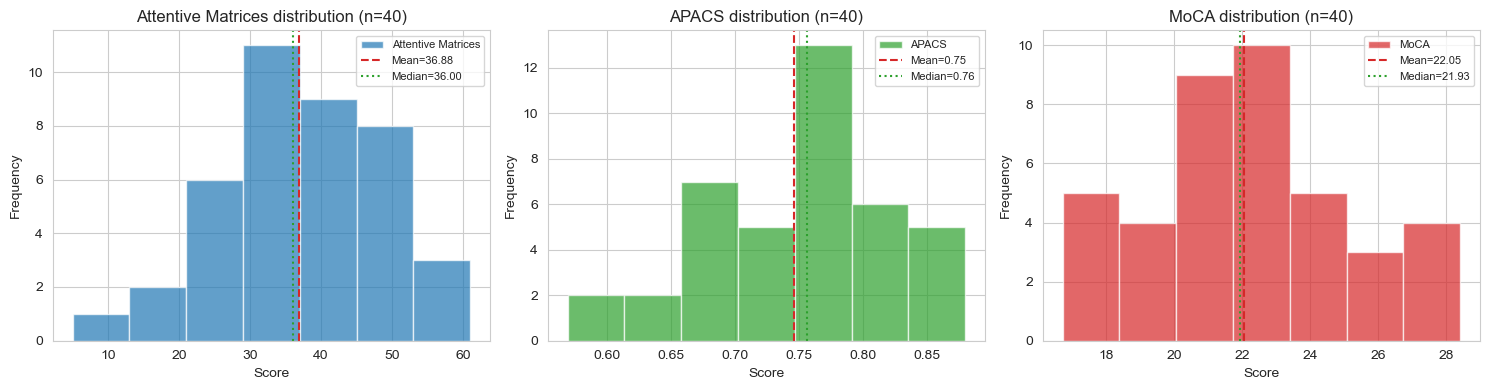

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scores = [
    ("att_matr", "Attentive Matrices", "tab:blue"),
    ("apacs", "APACS", "tab:green"),
    ("moca", "MoCA", "tab:red"),
]

df = pd.DataFrame({
    "apacs": apacs.round(4), "att_matr": att_matr.round(2), "moca": moca.round(2),
})
df.head()

for ax, (name, label, color) in zip(axes, scores):
    vals = df[name]
    ax.hist(vals, bins="auto", edgecolor="white", alpha=0.7, color=color, label=label)
    ax.axvline(vals.mean(), color="C3", ls="--", label=f"Mean={vals.mean():.2f}")
    ax.axvline(np.median(vals), color="C2", ls=":", label=f"Median={np.median(vals):.2f}")
    ax.set_xlabel("Score")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{label} distribution (n={N_SUBJECTS})")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 5. Step 4 — Quick check

Before exporting, we combine everything in one table and verify that the associations we want really show up.

First, a look at the data:

In [108]:
df = pd.DataFrame({
    "subject_id": [f"sub-{i+1:03d}" for i in range(N_SUBJECTS)],
    "age": age.round(1), "sex": sex, "criq": criq.round(1),
    "n400_amp": n400_amp.round(3), "n400_lat": n400_lat.round(1),
    "p300_amp": p300_amp.round(3), "p300_lat": p300_lat.round(1),
    "apacs": apacs.round(4), "att_matr": att_matr.round(1), "moca": moca.round(2),
})
df.head()

,subject_id,age,sex,criq,n400_amp,n400_lat,p300_amp,p300_lat,apacs,att_matr,moca
0,sub-001,68.0,0,108.5,4.781,419.0,12.491,335.6,0.8207,51.0,20.53
1,sub-002,55.0,1,98.4,3.309,402.2,12.206,337.1,0.7716,46.0,23.32
2,sub-003,73.0,1,104.5,2.681,414.5,13.108,340.8,0.7531,43.0,21.15
3,sub-004,74.0,0,87.4,3.643,418.6,15.033,353.1,0.7062,25.0,21.81
4,sub-005,45.0,1,100.6,3.676,446.9,12.663,313.6,0.8480,61.0,27.36


Then the correlation matrix. Look at the blocks we care about:

- `p300_amp` **+** `att_matr` (p300_lat shows only a small indirect negative link, via age)
- `n400_amp` **+** `apacs`, `n400_lat` **−** `apacs`
- `sex` close to 0 everywhere

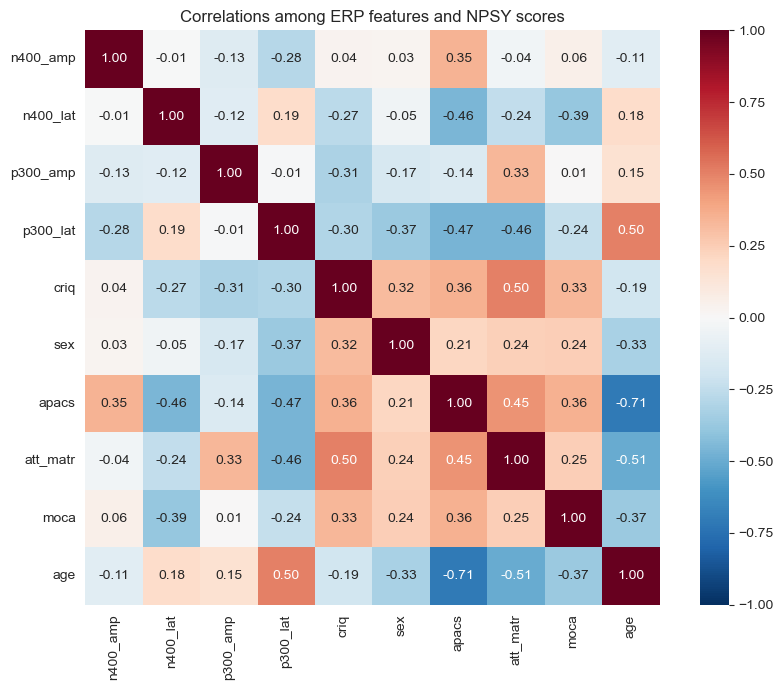

In [109]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[["n400_amp", "n400_lat", "p300_amp", "p300_lat","criq","sex", "apacs", "att_matr", "moca","age"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, square=True, ax=ax)
ax.set_title("Correlations among ERP features and NPSY scores")
plt.tight_layout()
plt.show()

Finally, a preview of the two analyses the case study will run, so we know the mock data "works":

1. **Attentive Matrices ~ P300 amplitude** + age + criq + sex
2. **APACS**: a "kitchen sink" model with all four ERP features vs. a parsimonious one with only the two N400 features

All variables are standardised, so the coefficients are comparable (standardised betas).

In [110]:
import statsmodels.api as sm

def standardize(x):
    return (x - x.mean()) / x.std(ddof=1)

def fit_std(df, formula):
    d = df.copy()
    d.drop(columns="subject_id",inplace=True)
    for c in d.columns:
        d[c] = standardize(d[c])
    return smf.glm(formula=formula,data=d,family=sm.families.Gaussian()).fit()

mod_apacs_formula = "apacs ~ n400_lat + n400_amp + age"
mod_apacs = fit_std(df, mod_apacs_formula)
print(f"APACS model: {mod_apacs_formula}")
print(f"  N400 amplitude: beta = {mod_apacs.params['n400_amp']:+.2f},  p = {mod_apacs.pvalues['n400_amp']:.3f}")
print(f"  N400 latency:   beta = {mod_apacs.params['n400_lat']:+.2f},  p = {mod_apacs.pvalues['n400_lat']:.3f}")

mod_matr_full_formula = "att_matr ~ p300_lat + p300_amp + n400_lat + n400_amp + age + sex + criq"
mod_matr_full = fit_std(df, mod_matr_full_formula)
mod_matr_pars_formula = "att_matr ~ p300_amp + age + criq"
mod_matr_pars = fit_std(df, mod_matr_pars_formula)

print(f"\nAtt. Matr. (full): {mod_matr_full_formula}")
print(f"  P300 amplitude: beta = {mod_matr_full.params['p300_amp']:+.2f},  p = {mod_matr_full.pvalues['p300_amp']:.3f}")
print(f"\nAtt. Matr. (pars): {mod_matr_pars_formula}")
print(f"  P300 amplitude: beta = {mod_matr_pars.params['p300_amp']:+.2f},  p = {mod_matr_pars.pvalues['p300_amp']:.3f}")
print("\nModel comparison (Attentive Matrices):")
print(f"  Kitchen sink: adj. R2 = {mod_matr_full.pseudo_rsquared():.3f},  AIC = {mod_matr_full.aic:.1f}")
print(f"  Parsimonious: adj. R2 = {mod_matr_pars.pseudo_rsquared():.3f},  AIC = {mod_matr_pars.aic:.1f}")

APACS model: apacs ~ n400_lat + n400_amp + age
  N400 amplitude: beta = +0.27,  p = 0.003
  N400 latency:   beta = -0.35,  p = 0.000

Att. Matr. (full): att_matr ~ p300_lat + p300_amp + n400_lat + n400_amp + age + sex + criq
  P300 amplitude: beta = +0.59,  p = 0.000

Att. Matr. (pars): att_matr ~ p300_amp + age + criq
  P300 amplitude: beta = +0.59,  p = 0.000

Model comparison (Attentive Matrices):
  Kitchen sink: adj. R2 = 0.913,  AIC = 72.8
  Parsimonious: adj. R2 = 0.924,  AIC = 66.5


> **What to look for:** the P300 amplitude effect on Matrici and the N400 effects on APACS should be significant (p < 0.05), and the parsimonious model should be at least as good as the kitchen sink (similar or better adjusted R², lower AIC). If these checks fail, the mock data would not be useful for the case study.

## 6. Step 5 — Save the two datasets

We split the data into two files, linked by `subject_id`. The case study will merge them back together — merging on a shared key is itself a useful skill to teach.

The notebook lives in `data/Code/`, so the files are saved one folder up, in `data/`.

In [ ]:
from pathlib import Path

out_dir = Path.cwd().parent  # data/  (this notebook is in data/Code/)

df_npsy = df[["subject_id", "age", "sex", "criq", "apacs", "att_matr", "moca"]]
df_eeg  = df[["subject_id", "n400_amp", "n400_lat", "p300_amp", "p300_lat"]]

df_npsy.to_csv(out_dir / "dataset_NPSY.csv", index=False)
df_eeg.to_csv(out_dir / "dataset_P300.csv", index=False)

print(f"Saved {df_npsy.shape}  -> {out_dir / 'dataset_NPSY.csv'}")
print(f"Saved {df_eeg.shape}  -> {out_dir / 'dataset_P300.csv'}")

Saved (40, 7)  -> /home/ale/SanCamillo/EEG_NPSI_BuonePratiche/EEG_NPSY_tutorial/data/dataset_NPSY.csv
Saved (40, 5)  -> /home/ale/SanCamillo/EEG_NPSI_BuonePratiche/EEG_NPSY_tutorial/data/dataset_P300.csv


Done! Both CSV files are ready to be used by **Case Study 1**.